The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

🔄 正在纵向切片提取 2-km 官方基准数据...


c:\tools\Anaconda\envs\pyscimis-test\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\tools\Anaconda\envs\pyscimis-test\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\GitHub\pyscimis\src\pyscimis\__init__.py:22: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  proj_x, 

🔄 正在穿透 30-m NetCDF 时空立方体...
📍 30-m NC 空间对齐成功！正在使用原始经纬度 (-120.414366, 37.354999) 进行像素穿透。


c:\tools\Anaconda\envs\pyscimis-test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) Garamond.
  fig.canvas.print_figure(bytes_io, **kw)
c:\tools\Anaconda\envs\pyscimis-test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from font(s) Garamond.
  fig.canvas.print_figure(bytes_io, **kw)
c:\tools\Anaconda\envs\pyscimis-test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) Garamond.
  fig.canvas.print_figure(bytes_io, **kw)
c:\tools\Anaconda\envs\pyscimis-test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from font(s) Garamond.
  fig.canvas.print_figure(bytes_io, **kw)
c:\tools\Anaconda\envs\pyscimis-test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33976 (\N{CJK UNIFIED 

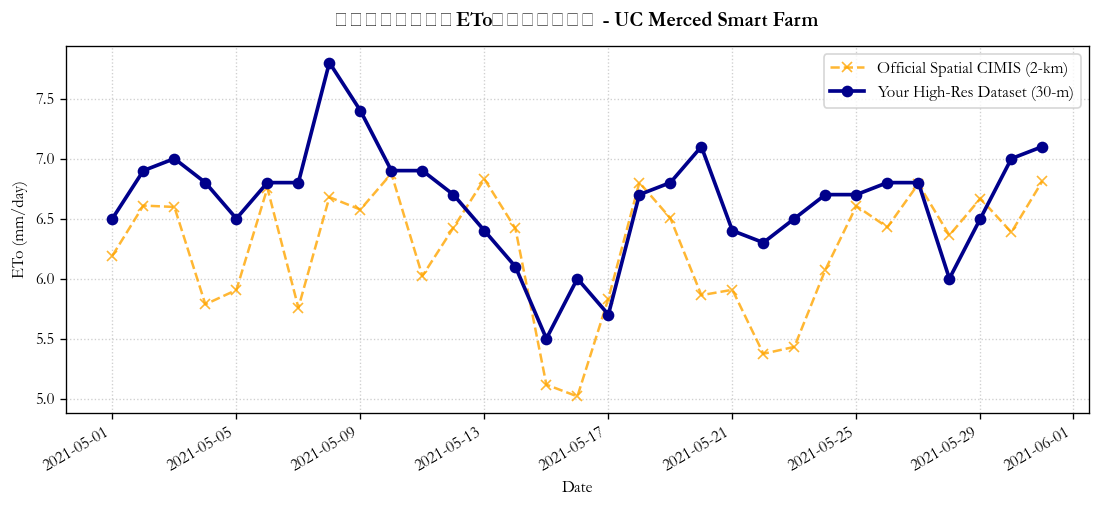

✨ 双尺度时序提取完成！前 5 行联表数据对照：
                 ETo  ETo_30m
Date                         
2021-05-01  6.191258      6.5
2021-05-02  6.608755      6.9
2021-05-03  6.597077      7.0
2021-05-04  5.785779      6.8
2021-05-05  5.905385      6.5


In [7]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pyscimis
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Garamond', 'Adobe Garamond Pro', 'EB Garamond', 'Times New Roman']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# =====================================================================
# 🎯 核心修正：精准挂载你完美的 D 盘物理路径
# =====================================================================
CIMIS_DATA_DIR = r"D:\1_Postdoc\0_Data\4_CIMIS_Spatial\Download"
MY_NC_DATA_DIR = r"E:\6_ETo_30m"

# 假设我们切片提取 2021 年 5 月的数据进行交叉验证
NC_FILE_PATH = Path(MY_NC_DATA_DIR) / "CA_ETo_2021_05.nc" 

start_date = "2021-01-01"
end_date = "2021-06-30"

farm_name = "UC Merced Smart Farm"
latitude = 37.354999
longitude = -120.414366

# 初始化提取引擎
extractor = pyscimis.LocalSpatialCimis(data_root_dir=CIMIS_DATA_DIR)

# =====================================================================
# 提取与作图
# =====================================================================
print("\n🔄 正在纵向切片提取 2-km 官方基准数据...")
df_cimis = extractor.extract_time_series(latitude=latitude, longitude=longitude, start_date=start_date, end_date=end_date, variable="ETo")
# df_cimis = pyscimis.convert_eto_to_metric(df_cimis_raw, column_name="ETo")

print("🔄 正在穿透 30-m NetCDF 时空立方体...")
df_my_30m = extractor.extract_from_nc_dataset(nc_path=NC_FILE_PATH, latitude=latitude, longitude=longitude, start_date=start_date, end_date=end_date, var_name="eto")

# 联表强行按日期对齐
df_combined = df_cimis.join(df_my_30m, how="inner")

# 📊 绘制双尺度科研比对大图
plt.figure(figsize=(11, 4.5), dpi=120)
plt.plot(df_combined.index, df_combined["ETo"], color="orange", linestyle="--", marker="x", alpha=0.8, label="Official Spatial CIMIS (2-km)")
plt.plot(df_combined.index, df_combined["ETo_30m"], color="darkblue", linestyle="-", marker="o", linewidth=2.2, label="Your High-Res Dataset (30-m)")

plt.title(f"多源参考蒸散发（ETo）时序交叉比对 - {farm_name}", fontsize=12, weight='bold', pad=12)
plt.xlabel("Date")
plt.ylabel("ETo (mm/day)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.gcf().autofmt_xdate()
plt.show()

print("✨ 双尺度时序提取完成！前 5 行联表数据对照：")
print(df_combined.head())